In [1381]:
import numpy as np
import pandas as pd
import json
import io
import math
from abc import abstractmethod
from datamodel import Listing, Observation, Order, OrderDepth, ProsperityEncoder, Symbol, Trade, TradingState
from enum import IntEnum
from statistics import NormalDist
import copy
import matplotlib.pyplot as plt 
import random
from collections import deque, defaultdict
from typing import List, Dict, Tuple, Optional, Any, TypeAlias
JSON: TypeAlias = dict[str, "JSON"] | list["JSON"] | str | int | float | bool | None

product_symbol = "RAINFOREST_RESIN"
product_symbol = "KELP"
product_symbol = "SQUID_INK"

market_data = pd.read_csv(r"C:\Users\Can\OneDrive\Desktop\IMC\R1\round-1-island-data-bottle\prices_round_1_day_0.csv", sep=";", header=0)
trade_history = pd.read_csv(r"C:\Users\Can\OneDrive\Desktop\IMC\R1\round-1-island-data-bottle\trades_round_1_day_0.csv", sep=";", header=0)

In [ ]:
def get_mid_price(state: TradingState, symbol: str, method, min_vol: int = 15) -> float:
    order_depth = state.order_depths[symbol]
    if not order_depth.buy_orders or not order_depth.sell_orders:
        return 0.0

    best_bid = max(order_depth.buy_orders.keys())
    best_ask = min(order_depth.sell_orders.keys())
    total_ask = sum(-price * qty for price, qty in order_depth.sell_orders.items())
    total_bid = sum(price * qty for price, qty in order_depth.buy_orders.items())
    qty_ask = sum(-qty for qty in order_depth.sell_orders.values())
    qty_bid = sum(order_depth.buy_orders.values())

    filtered_best_ask = min([p for p, q in order_depth.sell_orders.items() if -q >= min_vol], default=best_ask)
    filtered_best_bid = max([p for p, q in order_depth.buy_orders.items() if q >= min_vol], default=best_bid)

    mid = (best_bid + best_ask) / 2
    weighted_avg = (total_ask + total_bid) / (qty_ask + qty_bid)
    filtered_mid = (filtered_best_ask + filtered_best_bid) / 2 if filtered_best_ask and filtered_best_bid else mid

    popular_bid = max(order_depth.buy_orders.items(), key=lambda tup: tup[1])[0] if order_depth.buy_orders else best_bid
    popular_ask = min(order_depth.sell_orders.items(), key=lambda tup: tup[1])[0] if order_depth.sell_orders else best_ask
    popular_price = (popular_bid + popular_ask) / 2

    return {
        'mid_price': mid,
        'popular_price': popular_price,
        'weighted_average': weighted_avg,
        'filtered_mid_price': filtered_mid,
        'ensemble': (weighted_avg + filtered_mid) / 2
    }.get(method, mid)


def compute_volatility(history: deque, window_size: int = 10) -> float:
    if len(history) < window_size:
        return 0.0
    prices = list(history)[-window_size:]
    return float(np.std(prices))


def get_moving_average(history: deque, symbol: str, method: str, window_size: int, min_vol: int) -> Optional[float]:
    if len(history) < window_size:
        return None
    values = [
        get_mid_price(state, symbol, method, min_vol)
        for state in list(history)[-window_size:]
    ]
    return sum(values) / window_size


def aggressive_take_orders(symbol, state, true_value, remaining_buy, remaining_sell,
                           take_width, prevent_adverse=False, adverse_volume=0):
    order_depth = state.order_depths[symbol]
    orders = []
    buy_price_take = math.floor(true_value - take_width)
    sell_price_take = math.ceil(true_value + take_width)
    for price, volume in sorted(order_depth.sell_orders.items()):
        if remaining_buy > 0 and price <= buy_price_take and (not prevent_adverse or abs(volume) <= adverse_volume):
            quantity = min(remaining_buy, -volume)
            orders.append(Order(symbol, price, quantity))
            remaining_buy -= quantity
    for price, volume in sorted(order_depth.buy_orders.items(), reverse=True):
        if remaining_sell > 0 and price >= sell_price_take and (not prevent_adverse or volume <= adverse_volume):
            quantity = min(remaining_sell, volume)
            orders.append(Order(symbol, price, -quantity))
            remaining_sell -= quantity
    return orders, remaining_buy, remaining_sell

def clear_position_liquidation(symbol, state, limit, true_value, position, remaining_buy, remaining_sell, liquidate_width):
    orders = []
    order_depth = state.order_depths[symbol]

    to_clear = position - remaining_buy + remaining_sell

    # if to_clear < -limit*0.8:
    #     buy_price_liquidate = round(true_value - liquidate_width + 0.5)
    # else:
    #     buy_price_liquidate = round(true_value - liquidate_width)
    
    # if to_clear > limit*0.8:
    #     sell_price_liquidate = round(true_value + liquidate_width - 0.5)
    # else:
    #     sell_price_liquidate = round(true_value + liquidate_width)

    buy_price_liquidate = round(true_value - liquidate_width)
    sell_price_liquidate = round(true_value + liquidate_width)
    if to_clear > 0:
        clear_quantity = sum(
            volume for price, volume in order_depth.buy_orders.items()
            if price >= sell_price_liquidate
        )
        sent = min(to_clear, clear_quantity)
        if sent > 0:
            orders.append(Order(symbol, sell_price_liquidate, -sent))
            remaining_sell -= sent
    elif to_clear < 0:
        clear_quantity = sum(
            -volume for price, volume in order_depth.sell_orders.items()
            if price <= buy_price_liquidate
        )
        sent = min(-to_clear, clear_quantity)
        if sent > 0:
            orders.append(Order(symbol, buy_price_liquidate, sent))
            remaining_buy -= sent
    return orders, remaining_buy, remaining_sell

def no_liquidation(symbol, state, limit, true_value, position, remaining_buy, remaining_sell, liquidate_width):
    return [], remaining_buy, remaining_sell

def default_market_make(symbol, state, limit, true_value, remaining_buy, remaining_sell,
                        market_make_spread, price_filter_width, fallback_offset):
    orders = []
    order_depth = state.order_depths[symbol]
    position = state.position.get(symbol, 0)
    sell_prices = [price for price in order_depth.sell_orders if price > true_value + price_filter_width]
    buy_prices = [price for price in order_depth.buy_orders if price < true_value - price_filter_width]
    sell_base = min(sell_prices) if sell_prices else true_value + fallback_offset
    buy_base = max(buy_prices) if buy_prices else true_value - fallback_offset

    # if position > limit*0.8:
    #     market_make_spread_buy = market_make_spread - 0.5
    # else:
    #     market_make_spread_buy = market_make_spread
    # if position < -limit*0.8:
    #     market_make_spread_sell = market_make_spread + 0.5
    # else:
    #     market_make_spread_sell = market_make_spread

    # if position > limit*0.8:
    #     market_make_spread_sell = market_make_spread - 0.5
    # else:
    #     market_make_spread_sell = market_make_spread
    # if position < -limit*0.8:
    #     market_make_spread_buy = market_make_spread + 0.5
    # else:
    #     market_make_spread_buy = market_make_spread

    # buy_price_make = round(buy_base - market_make_spread_buy)
    # sell_price_make = round(sell_base + market_make_spread_sell)

    buy_price_make = round(buy_base - market_make_spread)
    sell_price_make = round(sell_base + market_make_spread)

    if remaining_buy > 0:
        orders.append(Order(symbol, buy_price_make, remaining_buy))
    if remaining_sell > 0:
        orders.append(Order(symbol, sell_price_make, -remaining_sell))
    return orders

class QLearningController:
    def __init__(self, actions, alpha=0.3, gamma=0.95, epsilon=0.3):
        self.actions = actions
        self.Q = defaultdict(lambda: np.zeros(len(self.actions)))
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

    def select_action_with_index(self, state):
        if random.random() < self.epsilon:
            idx = random.randint(0, len(self.actions) - 1)
        else:
            idx = int(np.argmax(self.Q[state]))
        return idx, self.actions[idx]

    def update(self, last_state, last_action, reward, next_state):
        if last_state is None or last_action is None:
            return
        if last_action >= len(self.actions):
            return
        q_old = self.Q[last_state][last_action]
        q_max_next = np.max(self.Q[next_state])
        self.Q[last_state][last_action] = q_old + self.alpha * (reward + self.gamma * q_max_next - q_old)

    def save(self):
        return {str(k): list(v) for k, v in self.Q.items()}

    def load(self, q_table):
        self.Q = defaultdict(lambda: np.zeros(len(self.actions)))
        for k, v in q_table.items():
            self.Q[eval(k)] = np.array(v)


class MarketMakingStrategy:
    def __init__(self, symbol: str, limit: int, print_log: int = 0,
                 take_order_fn=None, take_order_args=None,
                 liquidation_fn=None, liquidation_args=None,
                 market_make_fn=None, market_make_args=None,
                 true_value_args=None):
        self.symbol = symbol
        self.limit = limit
        self.print_log = print_log
        self.price_history_dict = defaultdict(lambda: deque(maxlen=50))
        self.take_order_fn = take_order_fn
        self.take_order_args = take_order_args or {}
        
        self.liquidation_fn = liquidation_fn
        self.liquidation_args = liquidation_args or {}

        self.market_make_fn = market_make_fn
        self.market_make_args = market_make_args or {}

        self.true_value_args = true_value_args or {}

        # self.history = deque(maxlen=10)
        self.true_value_history = deque(maxlen=30)
        self.window = deque()
        self.window_size = 3

        self.remaining_buy = 0
        self.remaining_sell = 0

        self.orders = []
        self.conversions = 0

    def run(self, state: TradingState) -> tuple[list[Order], int]:
        self.orders = []
        self.conversions = 0
        self.true_value_history = deque(maxlen=30)
        true_value = self.get_true_value(state)
        self.act(state, true_value)
        return self.orders, self.conversions

    def act(self, state: TradingState, true_value: float):
        position = state.position.get(self.symbol, 0)
        self.remaining_buy = self.limit - position
        self.remaining_sell = self.limit + position

        self.window.append(abs(position) == self.limit)
        if len(self.window) > self.window_size:
            self.window.popleft()

        print('startstart') if self.print_log == 1 else None
        print(f"to_buy{self.remaining_buy}...") if self.print_log == 1 else None
        print(f"to_sell{self.remaining_sell}...") if self.print_log == 1 else None
        print(f"position{position}...") if self.print_log == 1 else None

        if self.take_order_fn:
            orders, self.remaining_buy, self.remaining_sell = self.take_order_fn(
                self.symbol, state, true_value,
                self.remaining_buy, self.remaining_sell,
                **self.take_order_args
            )
            self.orders.extend(orders)
            if self.print_log:
                for o in orders:
                    print(f"[{self.symbol}] TAKE → {'BUY' if o.quantity > 0 else 'SELL'} {abs(o.quantity)} @ {o.price}") if self.print_log == 1 else None

        if self.liquidation_fn:
            orders, self.remaining_buy, self.remaining_sell = self.liquidation_fn(
                self.symbol, state, self.limit, true_value,
                position,
                self.remaining_buy, self.remaining_sell,
                **self.liquidation_args
            )
            self.orders.extend(orders)
            if self.print_log:
                for o in orders:
                    print(f"[{self.symbol}] LIQUIDATE → {'BUY' if o.quantity > 0 else 'SELL'} {abs(o.quantity)} @ {o.price}") if self.print_log == 1 else None

        if self.market_make_fn:
            orders = self.market_make_fn(
                self.symbol, state, self.limit, true_value,
                self.remaining_buy, self.remaining_sell,
                **self.market_make_args
            )
            self.orders.extend(orders)
            if self.print_log:
                for o in orders:
                    print(f"[{self.symbol}] MAKE → {'BUY' if o.quantity > 0 else 'SELL'} {abs(o.quantity)} @ {o.price}") if self.print_log == 1 else None

        print('endend') if self.print_log == 1 else None

    def get_true_value(self, state: TradingState) -> float:
        use_fixed = self.true_value_args.get("use_fixed", False)
        fixed_value = self.true_value_args.get("fixed_value", None)
        if use_fixed and fixed_value is not None:
            return fixed_value

        method = self.true_value_args.get("method")
        min_vol = self.true_value_args.get("min_vol")
        ma_window = self.true_value_args.get("ma_window")
        current_price = get_mid_price(state, self.symbol, method=method, min_vol=min_vol)
        # return current_price
        if self.symbol == "SQUID_INK":
            history = self.price_history_dict[self.symbol]
            history.append(current_price)
            if len(history) >= ma_window:
                return sum(history[-ma_window:]) / len(history[-ma_window:])
            else:
                return current_price
        # elif self.symbol == "KELP":
        #     return (get_mid_price(state, self.symbol, 'mid_price', min_vol=min_vol) - get_mid_price(state, self.symbol, 'weighted_average', min_vol=min_vol))*1 +get_mid_price(state, self.symbol, 'weighted_average', min_vol=min_vol)
        else:
            return current_price
        
    def save(self):
        return list(self.window)

    def load(self, data):
        self.window = deque(data) if data else deque()


class Trader:
    def __init__(self):
        self.print_log = 0
        # self.symbols = ["KELP", "RAINFOREST_RESIN","SQUID_INK"]
        self.symbols = [product_symbol]

        self.q_controllers = {
            "KELP": QLearningController(actions=[
                {"take_width": 1000, "market_make_spread": -1, "price_filter_width": 1, "fallback_offset": 0.5, "liquidate_width": 1},
                # {"take_width": 1, "market_make_spread": -1, "price_filter_width": 1, "fallback_offset": 1, "liquidate_width": 1},
                # {"take_width": 1, "market_make_spread": -1, "price_filter_width": 1, "fallback_offset": 1.5, "liquidate_width": 1},
                # {"take_width": 1, "market_make_spread": -1, "price_filter_width": 1, "fallback_offset": 2, "liquidate_width": 1},    
            ]),
            "RAINFOREST_RESIN": QLearningController(actions=[
                {"take_width": 1, "market_make_spread": -1, "price_filter_width": 1, "fallback_offset": 0.5, "liquidate_width": 1},
                # {"take_width": 1, "market_make_spread": -1, "price_filter_width": 1, "fallback_offset": 1, "liquidate_width": 1},
                # {"take_width": 1, "market_make_spread": -1, "price_filter_width": 1, "fallback_offset": 1.5, "liquidate_width": 1},
                # {"take_width": 1, "market_make_spread": -1, "price_filter_width": 1, "fallback_offset": 2, "liquidate_width": 1},
            ]),
            "SQUID_INK": QLearningController(actions=[
                # {'take_width': 1, 'market_make_spread': -1, 'price_filter_width': 2, 'fallback_offset': 2, 'liquidate_width': 0},
                # {'take_width': 1, 'market_make_spread': 0, 'price_filter_width': 2, 'fallback_offset': 2, 'liquidate_width': 2},
                # {'take_width': 1, 'market_make_spread': -0.5, 'price_filter_width': 2.5, 'fallback_offset': 2, 'liquidate_width': 1},
                {'take_width': 1, 'market_make_spread': -0.5, 'price_filter_width': 2.5, 'fallback_offset': 2, 'liquidate_width': 0.5},
            ]),
        }
# {'take_width': 1, 'market_make_spread': 0, 'price_filter_width': 2, 'fallback_offset': 2, 'liquidate_width': 2},
# {'take_width': 1, 'market_make_spread': -1, 'price_filter_width': 2, 'fallback_offset': 2, 'liquidate_width': 0},
        self.strategy_config = {
            "KELP": {
                "limit": 50,
                "take_order_args": {"prevent_adverse": True, "adverse_volume": 15},
                "liquidation_args": {},
                "market_make_args": {},
                "true_value_args": {
                    "use_fixed": False,
                    "method": "weighted_average",
                    "min_vol": 10,
                    "ma_window": 20
                }
            },
            "SQUID_INK": {
                "limit": 50,
                "take_order_args": {"prevent_adverse": True, "adverse_volume": 15},
                "liquidation_args": {},
                "market_make_args": {},
                "true_value_args": {
                    "use_fixed": False,
                    "method": "weighted_average",
                    "min_vol": 0,
                    "ma_window": 20
                }
            },
            "RAINFOREST_RESIN": {
                "limit": 50,
                "take_order_args": {"prevent_adverse": False, "adverse_volume": 15},
                "liquidation_args": {},
                "market_make_args": {},
                "true_value_args": {
                    "use_fixed": True,
                    "fixed_value": 10000,
                    "ma_window": 20
                }
            }
        }

        self.cashs = defaultdict(float)
        self.pnl = defaultdict(float)
        self.pnl_history = defaultdict(lambda: deque(maxlen=20))
        self.last_timestamp = -100
        self.last_states = {}
        self.last_actions = {}

        self.recent_prices = {sym: deque(maxlen=10) for sym in self.symbols}
        self.volatility_threshold = {"KELP": 50, "RAINFOREST_RESIN": 100, "SQUID_INK": 100}

    def get_state(self, symbol: str, state: TradingState) -> Tuple:
        position = state.position.get(symbol, 0)
        best_bid = max(state.order_depths[symbol].buy_orders.keys(), default=0)
        best_ask = min(state.order_depths[symbol].sell_orders.keys(), default=0)
        spread = best_ask - best_bid if best_bid and best_ask else 1

        if self.strategy_config[symbol]["true_value_args"].get("use_fixed", False):
            true_value = self.strategy_config[symbol]["true_value_args"]["fixed_value"]
        else:
            true_value = get_mid_price(state, symbol, method="weighted_average", min_vol=15)

        mid_price = (best_bid + best_ask) / 2 if best_bid and best_ask else true_value
        tv_diff = round(true_value - mid_price)
        clipped_position = max(-5, min(5, int(position / 10)))

        return (clipped_position, int(spread), tv_diff)

    def save_state(self) -> str:
        return json.dumps({
            "cashs": dict(self.cashs),
            "pnl": dict(self.pnl),
            "pnl_history": {k: list(v) for k, v in self.pnl_history.items()},
            "last_timestamp": self.last_timestamp,
            "q_tables": {sym: self.q_controllers[sym].save() for sym in self.symbols}
        })

    def load_state(self, data: str):
        if not data:
            return
        try:
            d = json.loads(data)
            self.cashs = defaultdict(float, d.get("cashs", {}))
            self.pnl = defaultdict(float, d.get("pnl", {}))
            self.last_timestamp = d.get("last_timestamp", -100)
            self.pnl_history = defaultdict(lambda: deque(maxlen=20), {
                k: deque(v, maxlen=20) for k, v in d.get("pnl_history", {}).items()
            })
            for sym in self.symbols:
                q_table = d.get("q_tables", {}).get(sym, {})
                self.q_controllers[sym].load(q_table)
        except Exception as e:
            print("[LOAD ERROR]", e)

    def run(self, state: TradingState) -> Tuple[Dict[str, List[Order]], int, str]:
        if state.traderData:
            self.load_state(state.traderData)

        all_orders = {}
        conversions = 0

        for symbol in self.symbols:
            for trade in state.own_trades.get(symbol, []):
                if trade.timestamp == self.last_timestamp:
                    if trade.buyer == "SUBMISSION":
                        self.cashs[symbol] -= trade.price * trade.quantity
                    elif trade.seller == "SUBMISSION":
                        self.cashs[symbol] += trade.price * trade.quantity
            if self.print_log:
                print(f"[{symbol}] own_trades: {state.own_trades.get(symbol, [])}")

        for symbol in self.symbols:
            cfg = self.strategy_config[symbol]
            q_ctrl = self.q_controllers[symbol]
            state_tuple = self.get_state(symbol, state)

            # 获取当前 true_value
            if cfg["true_value_args"].get("use_fixed", False):
                tv = cfg["true_value_args"]["fixed_value"]
            else:
                tv = get_mid_price(state, symbol, method="weighted_average", min_vol=15)

            # 📈 更新 price 窗口并检测波动
            price_history = self.recent_prices[symbol]
            price_history.append(tv)

            if len(price_history) == price_history.maxlen:
                returns = np.diff(price_history)
                volatility = np.std(returns)

                if volatility > self.volatility_threshold[symbol]:
                    print(f"[{symbol}] 🚨 High volatility detected! Skipping round.")
                    continue  # 跳过这一轮

            action_idx, params = q_ctrl.select_action_with_index(state_tuple)
            self.last_states[symbol] = state_tuple
            self.last_actions[symbol] = action_idx

            if self.print_log:
                print(f"[{symbol}] Action Index: {action_idx}")

            strat = MarketMakingStrategy(
                symbol=symbol,
                limit=cfg["limit"],
                print_log=self.print_log,
                take_order_fn=aggressive_take_orders,
                take_order_args={**cfg["take_order_args"], "take_width": params["take_width"]},
                liquidation_fn=clear_position_liquidation,
                liquidation_args={**cfg["liquidation_args"], "liquidate_width": params["liquidate_width"]},
                market_make_fn=default_market_make,
                market_make_args={
                    **cfg["market_make_args"],
                    "market_make_spread": params["market_make_spread"],
                    "price_filter_width": params["price_filter_width"],
                    "fallback_offset": params["fallback_offset"]
                },
                true_value_args=cfg["true_value_args"]
            )

            orders, conv = strat.run(state)
            tv = strat.get_true_value(state)
            pos = state.position.get(symbol, 0)
            pnl_now = self.cashs[symbol] + pos * tv
            self.pnl[symbol] = pnl_now
            self.pnl_history[symbol].append(pnl_now)

            reward = 0
            if len(self.pnl_history[symbol]) >= 15:
                reward = self.pnl_history[symbol][-1] - self.pnl_history[symbol][0]

            q_ctrl.update(self.last_states[symbol], self.last_actions[symbol], reward, self.get_state(symbol, state))

            all_orders[symbol] = orders
            conversions += conv

            if self.print_log:
                print(f"[{symbol}] PnL: {pnl_now:.2f}, Cash: {self.cashs[symbol]:.2f}, Pos: {pos}, TV: {tv:.2f}, Reward: {reward:.2f}")

        self.last_timestamp = state.timestamp
        return all_orders, conversions, self.save_state()

In [1383]:
def _construct_order_depths(group):
    order_depths = {}
    for idx, row in group.iterrows():
        product = row['product']
        order_depth = OrderDepth()
        for i in range(1, 4):
            if f'bid_price_{i}' in row and f'bid_volume_{i}' in row:
                bid_price = row[f'bid_price_{i}']
                bid_volume = row[f'bid_volume_{i}']
                if not pd.isna(bid_price) and not pd.isna(bid_volume):
                    order_depth.buy_orders[int(bid_price)] = int(bid_volume)
            if f'ask_price_{i}' in row and f'ask_volume_{i}' in row:
                ask_price = row[f'ask_price_{i}']
                ask_volume = row[f'ask_volume_{i}']
                if not pd.isna(ask_price) and not pd.isna(ask_volume):
                    order_depth.sell_orders[int(ask_price)] = -int(ask_volume)
        order_depths[product] = order_depth
    return order_depths


def _construct_trading_state(traderData, timestamp, listings, order_depths, 
                                own_trades, market_trades, position, observations):
    state = TradingState(traderData, timestamp, listings, order_depths, own_trades, market_trades, position, observations)
    return state


def _execute_buy_order(timestamp, order, order_depths, position, cash, trade_history_dict, sandboxLog):
        trades = []
        order_depth = order_depths[order.symbol]

        for price, volume in list(order_depth.sell_orders.items()):
            if price > order.price or order.quantity == 0:
                break

            trade_volume = min(abs(order.quantity), abs(volume))
            if abs(trade_volume + position[order.symbol]) <= int(position_limit[order.symbol]):
                trades.append(Trade(order.symbol, price, trade_volume, "SUBMISSION", "", timestamp))
                position[order.symbol] += trade_volume
                cash[order.symbol] = cash[order.symbol] - price * trade_volume
                order_depth.sell_orders[price] += trade_volume
                order.quantity -= trade_volume
            else:
                sandboxLog += f"\nOrders for product {order.symbol} exceeded limit of {position_limit[order.symbol]} set"
            
            if order_depth.sell_orders[price] == 0:
                del order_depth.sell_orders[price]
        
        trades_at_timestamp = trade_history_dict.get(timestamp, [])
        new_trades_at_timestamp = []
        for trade in trades_at_timestamp:
            if trade.symbol == order.symbol:
                if trade.price < order.price:
                    trade_volume = min(abs(order.quantity), abs(trade.quantity))
                    trades.append(Trade(order.symbol, order.price, trade_volume, "SUBMISSION", "", timestamp))
                    order.quantity -= trade_volume
                    position[order.symbol] += trade_volume
                    cash[order.symbol] = cash[order.symbol] - order.price * trade_volume
                    if trade_volume == abs(trade.quantity):
                        continue
                    else:
                        new_quantity = trade.quantity - trade_volume
                        new_trades_at_timestamp.append(Trade(order.symbol, order.price, new_quantity, "", "", timestamp))
                        continue
            new_trades_at_timestamp.append(trade)  

        if len(new_trades_at_timestamp) > 0:
            trade_history_dict[timestamp] = new_trades_at_timestamp

        return trades, sandboxLog
        
def _execute_sell_order(timestamp, order, order_depths, position, cash, trade_history_dict, sandboxLog):
    trades = []
    order_depth = order_depths[order.symbol]
    
    for price, volume in sorted(order_depth.buy_orders.items(), reverse=True):
        if price < order.price or order.quantity == 0:
            break

        trade_volume = min(abs(order.quantity), abs(volume))
        if abs(position[order.symbol] - trade_volume) <= int(position_limit[order.symbol]):
            trades.append(Trade(order.symbol, price, trade_volume, "", "SUBMISSION", timestamp))
            position[order.symbol] -= trade_volume
            cash[order.symbol] = cash[order.symbol] + price * abs(trade_volume)
            order_depth.buy_orders[price] -= abs(trade_volume)
            order.quantity += trade_volume
        else:
            sandboxLog += f"\nOrders for product {order.symbol} exceeded limit of {position_limit[order.symbol]} set"

        if order_depth.buy_orders[price] == 0:
            del order_depth.buy_orders[price]

    trades_at_timestamp = trade_history_dict.get(timestamp, [])
    new_trades_at_timestamp = []
    for trade in trades_at_timestamp:
        if trade.symbol == order.symbol:
            if trade.price > order.price:
                trade_volume = min(abs(order.quantity), abs(trade.quantity))
                trades.append(Trade(order.symbol, order.price, trade_volume, "", "SUBMISSION", timestamp))
                order.quantity += trade_volume
                position[order.symbol] -= trade_volume
                cash[order.symbol] = cash[order.symbol] + order.price * trade_volume
                if trade_volume == abs(trade.quantity):
                    continue
                else:
                    new_quantity = trade.quantity - trade_volume
                    new_trades_at_timestamp.append(Trade(order.symbol, order.price, new_quantity, "", "", timestamp))
                    continue
        new_trades_at_timestamp.append(trade)  

    if len(new_trades_at_timestamp) > 0:
        trade_history_dict[timestamp] = new_trades_at_timestamp
            
    return trades, sandboxLog

def _execute_order(timestamp, order, order_depths, position, cash, trades_at_timestamp, sandboxLog):
    if order.quantity == 0:
        return [],[]
    
    order_depth = order_depths[order.symbol]
    if order.quantity > 0:
        return _execute_buy_order(timestamp, order, order_depths, position, cash, trades_at_timestamp, sandboxLog)
    else:
        return _execute_sell_order(timestamp, order, order_depths, position, cash, trades_at_timestamp, sandboxLog)
    

def _add_trades(own_trades: Dict[str, List[Trade]], market_trades: Dict[str, List[Trade]]):
    products = set(own_trades.keys()) | set(market_trades.keys())
    for product in products:
        trades.extend([_trade_to_dict(trade) for trade in own_trades.get(product, [])])
    for product in products:
        trades.extend([_trade_to_dict(trade) for trade in market_trades.get(product, [])])

def _mark_pnl(cash, position, order_depths, pnl, product):
    order_depth = order_depths[product]
    
    best_ask = min(order_depth.sell_orders.keys())
    best_bid = max(order_depth.buy_orders.keys())
    mid = (best_ask + best_bid)/2
    fair = mid
    
    if product == 'AMETHYSTS':
        fair = 10000
    pnl[product] = cash[product] + fair * position[product]

def _trade_to_dict(trade: Trade) -> dict[str, Any]:
    return {
        "timestamp": trade.timestamp,
        "buyer": trade.buyer,
        "seller": trade.seller,
        "symbol": trade.symbol,
        "currency": "SEASHELLS",
        "price": trade.price,
        "quantity": trade.quantity,
    }

def calculate_starfruit_fair(order_depth):
    # assumes order_depth has orders in it 
    best_ask = min(order_depth.sell_orders.keys())
    best_bid = max(order_depth.buy_orders.keys())
    filtered_ask = [price for price in order_depth.sell_orders.keys() if abs(order_depth.sell_orders[price]) >= 15]
    filtered_bid = [price for price in order_depth.buy_orders.keys() if abs(order_depth.buy_orders[price]) >= 15]
    mm_ask = min(filtered_ask) if len(filtered_ask) > 0 else best_ask
    mm_bid = max(filtered_bid) if len(filtered_bid) > 0 else best_bid

    mmmid_price = (mm_ask + mm_bid) / 2
    return mmmid_price

def calculate_amethysts_fair(order_depth):
    return 10000

In [1384]:
trader = Trader()

listings = {
    'RAINFOREST_RESIN': Listing(symbol='RAINFOREST_RESIN', product='RAINFOREST_RESIN', denomination='SEASHELLS'),
    'KELP': Listing(symbol='KELP', product='KELP', denomination='SEASHELLS'),
    'SQUID_INK': Listing(symbol='SQUID_INK', product='SQUID_INK', denomination='SEASHELLS')
}

position_limit = {
    'RAINFOREST_RESIN': 50,
    'KELP': 50,
    'SQUID_INK': 50,
}

# fair_marks = {
#     "AMETHYSTS": calculate_amethysts_fair,
#     "STARFRUIT": calculate_starfruit_fair
# }

timestamp_group_md = market_data.groupby('timestamp')
timestamp_group_th = trade_history.groupby('timestamp')

own_trades = defaultdict(list)
market_trades = defaultdict(list)
pnl_product = defaultdict(float)

trade_history_dict = {}

observations = [Observation({}, {}) for _ in range(len(market_data))]
current_position = {product: 0 for product in listings.keys()}

traderData = "" 

trade_history = trade_history.sort_values(by=['timestamp', 'symbol'])
observations = [Observation({}, {}) for _ in range(len(market_data))]
current_position = {product: 0 for product in listings.keys()}
pnl_history = {'RAINFOREST_RESIN': [],'KELP': [],'SQUID_INK': []}

pnl = {product: 0 for product in listings.keys()}
cash = {product: 0 for product in listings.keys()}
position_history = {'RAINFOREST_RESIN': [],'KELP': [],'SQUID_INK': []}

trades = []
sandbox_logs = []

In [1385]:
trade_history_dict = {
    timestamp: [
        Trade(
            row['symbol'],
            int(row['price']),
            int(row['quantity']),
            row['buyer'] if row['buyer'] == 'SUBMISSION' else "",
            row['seller'] if row['seller'] == 'SUBMISSION' else "",
            timestamp
        )
        for _, row in group.iterrows()
    ]
    for timestamp, group in timestamp_group_th
}

for count, (timestamp, group) in enumerate(timestamp_group_md):
    if count > 100000:
        break
    
    order_depths = _construct_order_depths(group)
    order_depths_matching = copy.deepcopy(order_depths)  # 模拟成交时会被修改
    order_depths_pnl = order_depths  # 只是用来计算 mid 估值，不会修改

    state = _construct_trading_state(
        traderData, timestamp, listings, order_depths,
        dict(own_trades), dict(market_trades),
        current_position, observations
    )

    orders, conversions, traderData = trader.run(state)

    products = group['product'].tolist()
    sandboxLog = ""
    trades_at_timestamp = trade_history_dict.get(timestamp, [])

    for product in products:
        new_trades = []
        for order in orders.get(product, []):
            trades_done, sandboxLog = _execute_order(
                timestamp, order, order_depths_matching,
                current_position, cash, trade_history_dict, sandboxLog
            )
            new_trades.extend(trades_done)
        if new_trades:
            own_trades[product] = new_trades

    sandbox_logs.append({
        "sandboxLog": sandboxLog,
        "lambdaLog": "",
        "timestamp": timestamp
    })

    if trades_at_timestamp:
        for trade in trades_at_timestamp:
            market_trades[trade.symbol].append(trade)
    else:
        for product in products:
            market_trades[product] = []

    for product in products:
        _mark_pnl(cash, current_position, order_depths_pnl, pnl, product)
        pnl_history[product].append(pnl[product])
        position_history[product].append(current_position[product])
    
    _add_trades(own_trades, market_trades)

In [1386]:
pnl

{'RAINFOREST_RESIN': 0.0, 'KELP': 0.0, 'SQUID_INK': 634.5}

In [1387]:
product_symbol = "RAINFOREST_RESIN"
product_symbol = "KELP"
product_symbol = "SQUID_INK"

weighted_average, popular_price
 0: 3569.5, 3556.5
-1: 4572.0, 4412.0
-2: 4602.0, 4780.0 

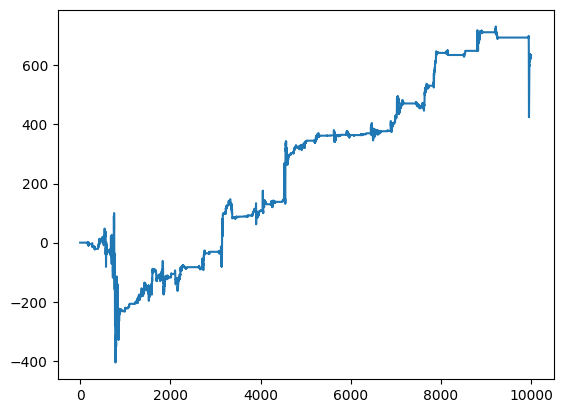

In [1388]:
plt.plot(pnl_history[product_symbol])

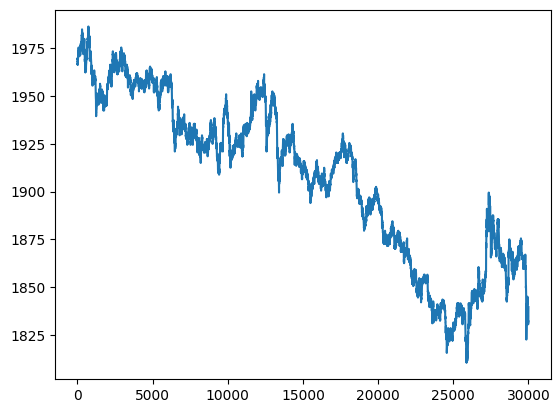

In [1389]:
plt.plot(market_data[market_data['product']==product_symbol]['mid_price'])

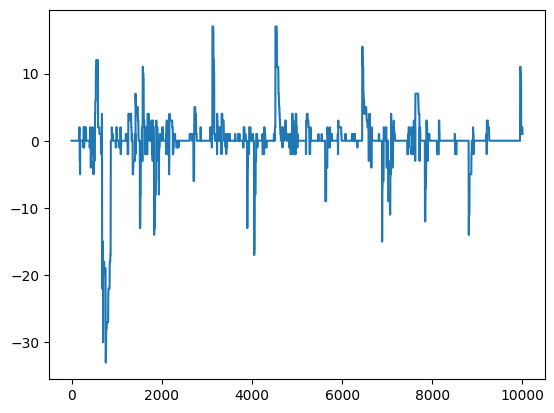

In [1390]:
plt.plot(position_history[product_symbol])